# (노트) 매트로폴리스-헤이스팅스
> 미완성

- toc:true
- branch: master
- badges: true
- comments: true
- author: 신록예찬
- categories: [통계계산]

### 예제1 

다시 $B(2.7,6.3)$을 추출하는 예제로 돌아가자. 

`-` 시도1: 사각형 틀을 만들고 그안에서 확률변수 발생시킴. (참조분포로 $U$를 사용)

`-` 시도2: $B(2,6)$을 발생시키고 그 안에서 확률변수를 발생시킴. (참조분포로 $B(2,6)$을 사용) 

`-` 시도1은 참조분포를 잡기 쉬웠지만 효율이 좋지 않았다. (효율이 약 36.95%)  반면 시도2는 참조분포를 잡기 까다로운 대신에 효율이 좋았음. (효율이 약 59.29%)

`-` 좀 더 좋은 방법이 없을까? (참조분포를 잡기 쉬우면서도 효율도 좋은?)

#### 시도1

`-` 우선 우리가 관심이 있는 타겟분포를 그려보자. 

In [2]:
f<-function(x){
    alpha=2.7
    beta=6.3
    gamma(alpha+beta)/gamma(alpha)/gamma(beta) * x^(alpha-1) * (1-x)^(beta-1)
}

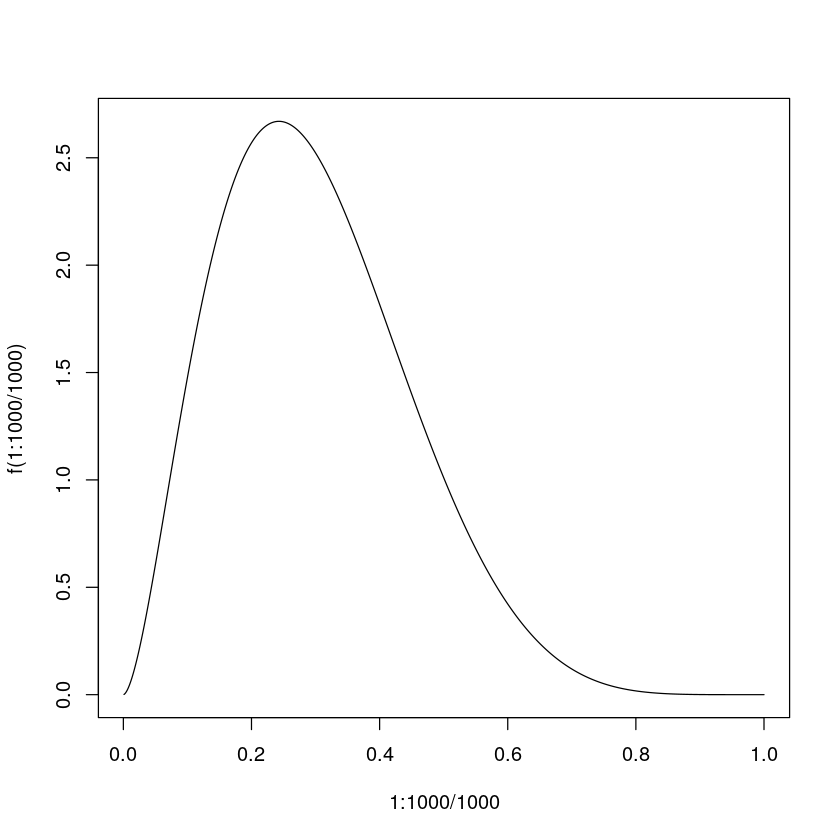

In [3]:
plot(1:1000/1000,f(1:1000/1000),type='l')

In [4]:
X<-rep(0.1,5000)

In [5]:
print(head(X))

[1] 0.1 0.1 0.1 0.1 0.1 0.1


`-` 현재 $X$의 값은 모두 0.1 이다. 그런데 궁극적으로는 $X$의 값을 모두 $Beta(2.7,6.3)$에서 생성된 샘플들로 채우고 싶다. 

In [6]:
set.seed(1)
Y<-runif(1)
print(Y)

[1] 0.2655087


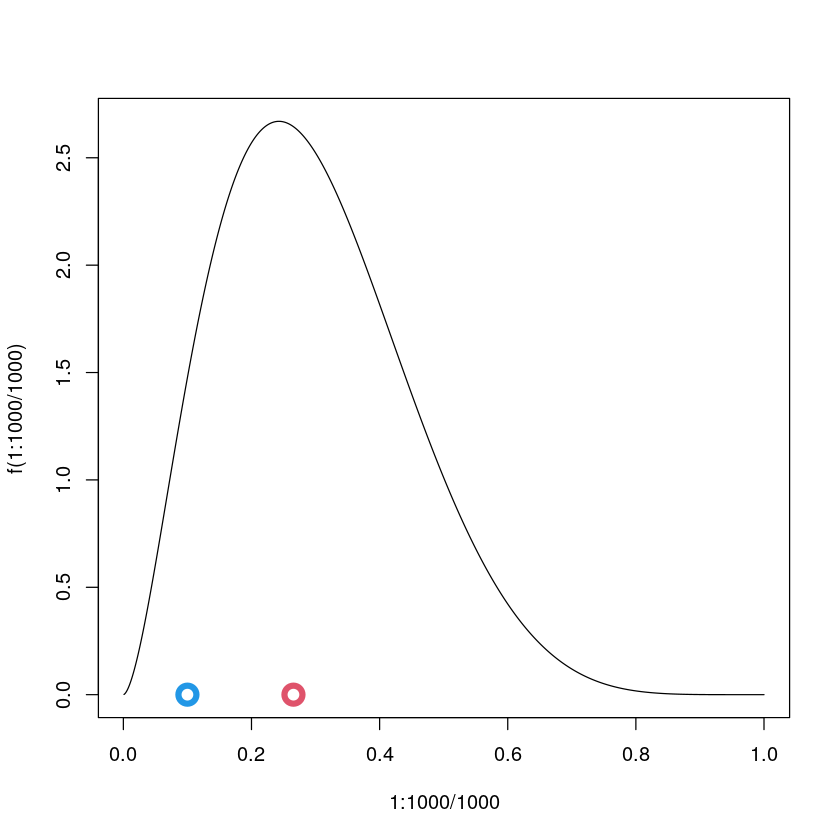

In [7]:
plot(1:1000/1000,f(1:1000/1000),type='l')
points(Y,0,col=2,cex=2,lwd=5)
points(X[1],0,col=4,cex=2,lwd=5)

`-` 빨간점은 $Y$이고 파란점은 $X$이다. 두개의 점중에서 어떤것이 $f(x)$에서 생성되었다고 믿어지는 점일까? 

`-` 빨간색 점이 더 가능성 있어보인다. (pdf값이 높음) 

`-` $X[2]$의 값은 그냥 빨강으로 결정하자. 

In [8]:
X[2]<-Y

`-` 다시 $Y$를 하나 뽑자. 

In [9]:
set.seed(2)
Y<-runif(1)
print(Y)

[1] 0.1848823


`-` 다시 뽑은 $Y$는 초록색으로 표현하자. 

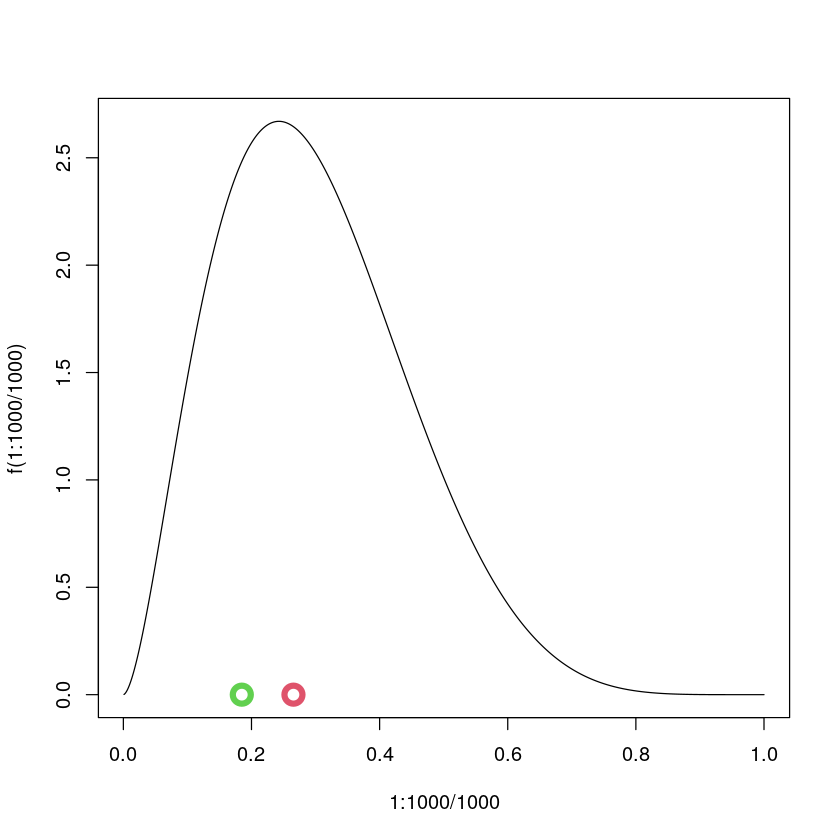

In [10]:
plot(1:1000/1000,f(1:1000/1000),type='l')
points(Y,0,col=3,cex=2,lwd=5)
points(X[2],0,col=2,cex=2,lwd=5)

`-` 둘중에 어떤것이 더 $Beta(2.7,6.3)$에서 추출한 샘플같은가? 

`-` 여전히 빨강이 더 $Beta(2.7,6.3)$의 분포에서 나온것 같다. 

`-` 그러면 $X[3]$의 값도 그냥 빨강으로 한다. 

`-` 지금까지의 결과를 요약하면 아래와 같다. 

|$t$|$X_t$|$Y_t$|설명|
|:-:|:-:|:-:|:-:|
|$1$|$0.1$|$0.2655087$|$Y_1$이 $X_1$보다 더 $Beta(2.7,6.3)$에서 나온 분포같다 $\to$ $X_2$는 $Y_1$으로 선택| 
|$2$|$0.2655087$|$0.1848823$|이번에는 $X_2$가 $Y_2$보다 더 $Beta(2.7,6.3)$에서 나온 분포같다 $\to$ $X_3$는 $X_2$로 선택| 
|$3$|$0.2655087$|$-$|$-$|
|$\dots$|$\dots$|$\dots$|$\dots$|


`-` 이걸 무한대로 반복하면 $X_t$는 결국 $Beta(2.7,6.3)$에서 뽑혔을법한 샘플들로 점점 가까워진다. 

`-` 따라서 $\{X_1,X_2,X_3,\dots,X_{1000000}\}$을 모아서 히스토그램을 그리면 적당히 $Beta(2.7,6.3)$에서 추출한 표본이라 주장할 수 있을것 같다. 

`-` 앞부분은 내가 임의로 값을 주는거에 따라 다르니까 대충 앞에 100개정도는 버리고 $\{X_{101},X_{102},X_{103},\dots,X_{1000000}\}$을 모아서 히스토그램을 그리면 더 좋은 그림이 나올것 같다. 

#### 시도2

`-` 시도1의 당연한 우려점은 특정시점 이후에는 $X_t$가 거의 하나의 값만 나올것 같다는 것이다. 

`-` 즉 우연히 $X_t$가 pdf의 최고점의 $x$축에 찍혀있다고 하자. 그러면 그 이후로는 $X_t$는 하나의 값만 나올것이다. 

`-` 당장 위의 그림만봐도 대략 빨간색점에서 거의 pdf가 최고점인데 왠지 $t=4,5,6,7\dots$ 를 돌려보아도 당분간은 $X_t=0.2655087$ 일 것 같다. 

`-` 히스토그램을 그려봤자 죄다 $0.2655087$에만 값이 몰려있을 것이다. 

`-` 더 그럴듯한 샘플을 선택하는 아이디어는 좋은데, 그런식으로 진행하면 결국 반복할수록 pdf의 최고점을 향해 달려가는 꼴밖에 안된다. 

`-` 다시 아래의 그림을 관찰하여 보자.

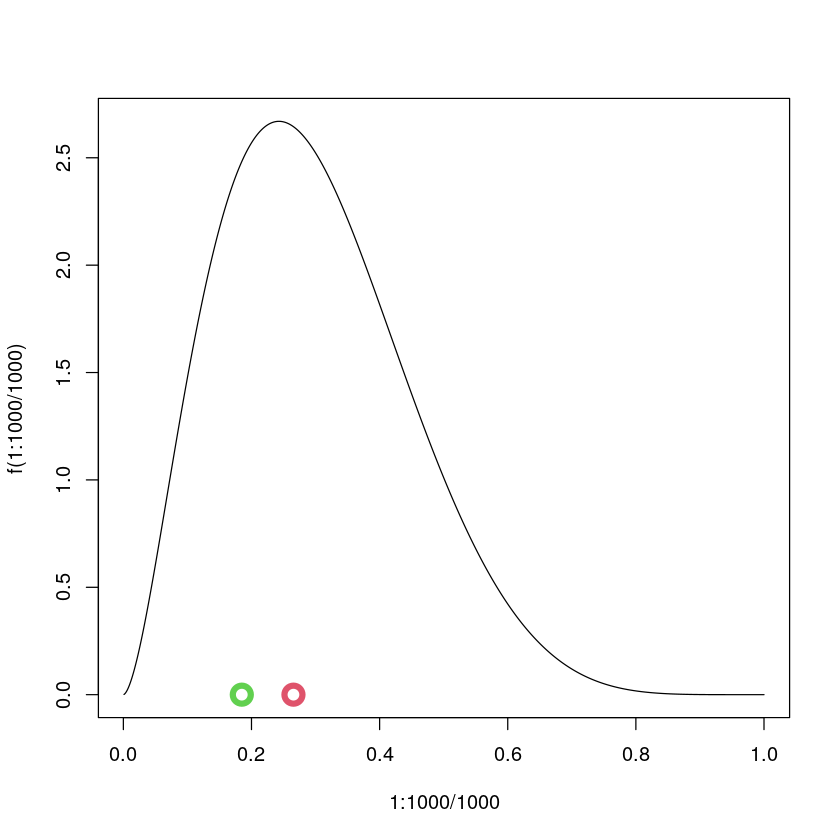

In [11]:
plot(1:1000/1000,f(1:1000/1000),type='l')
points(Y,0,col=3,cex=2,lwd=5)
points(X[2],0,col=2,cex=2,lwd=5)

`-` 초록색 점보다 빨간색 점이 더 pdf값이 높으므로 빨간색 점이 더 $Beta(2.7,6.3)$에서 나왔음 직한 샘플인것은 맞다. 

`-` 그런데 100% 확신할 수 있는가? 

`-` 빨간색점 0.2655087 에서의 pdf값은 아래와 같다. 

In [12]:
f(0.2655087)

[1] 2.644806

`-` 반면 초록색점 0.1848823 에서의 pdf값은 아래와 같다. 

In [13]:
f(0.1848823)

[1] 2.482678

`-` 사실 초록색 점도 가능성 있는 점이다. 만약에 어떤사람이 $Beta(2.7,6.3)$에서 확률변수를 하나 생성했다고 치자. 그리고 하나는 $U[0,1]$에서 생성했다고 치자. 두 결과를 초록색과 빨간색이라고 할때 어떤색이 $Beta(2.7,6.3)$에서 생성되었냐고 묻는다면 당신은 빨간색을 고를것이다. 

`-` 하지만 빨간색에 전재산을 베팅할 수 있는가? 

In [14]:
f(0.2655087)/(f(0.2655087)+f(0.1848823))

[1] 0.5158097

`-` 빨간색에 $51.58\%$의 재산정도만 베팅하는 것이 맞다. 

`-` 즉 빨간색이 진짜 $Beta(2.7,6.3)$에서 왔다고 믿을 확률은 51.58\% 정도라는 의미이다. 

`-` 그렇다면 알고리즘을 조금 수정해보는 것이 어떨까? 

`-` 제안하는 알고리즘 

(1) $X_1$에 아무값이나 넣는다. 

(2) 균등분포에서 $Y_1$을 뽑는다. 

(3) $\frac{f(Y_1)}{f(X_1)+f(Y_1)}$의 확률로 $X_2=Y_1$을 선택하고 $\frac{f(X_1)}{f(X_1)+f(Y_1)}$의 확률로 $X_2=X_1$을 선택한다. 

(4) (2)-(3)을 반복한다. 

`-` 실행

In [66]:
X<-rep(0.1,5000)
for (i in 2:5000){
    Y<-runif(1)
    acceptance_prob<-f(Y)/(f(X[i])+f(Y))
    U_ <- runif(1)
    X[i]<- Y * (U_<acceptance_prob) + X[i-1] * (U_>acceptance_prob)
}

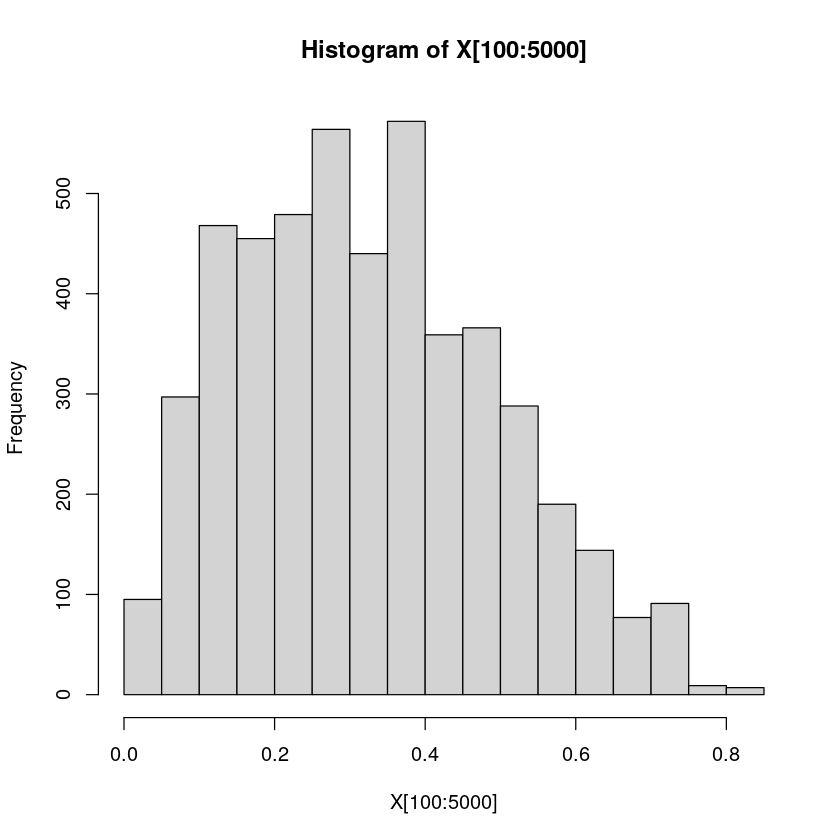

In [67]:
hist(X[100:5000])

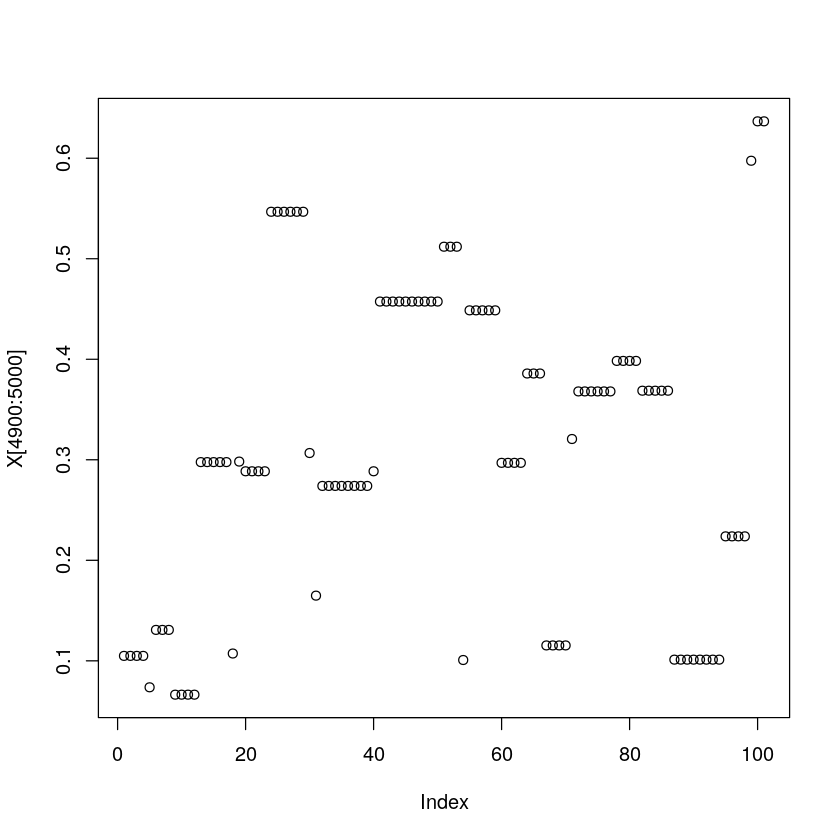

In [68]:
plot(X[4900:5000])

`-` 분명히 $X_t$는 $X_{t-1}$와 종속되어있다. 그런데 전체 분포를 그려보니까 $B(2.7,6.3)$의 히스토그램과 같다. 

`-` 이 알고리즘이 어떻게 성립하는가? 

`-` 그러고 보니까 이 느낌을 어디서 받았다.. (에르고딕, 정상성)

### 시도2의 이론적 근거

`-` 주장하고 싶은 것은 아래와 같다. 
- 타겟분포: $X_{t}$의 극한분포는 $Beta(2.7,6.3)$이다. 
- 에르고드성: $X_{\infty}$의 분포인 $Beta(2.7,6.3)$는 hist는 $X_{100}\dots \sim X_{\infty}$등의 샘플(타임샘플?)을 바탕으로 히스토그램을 그려도된다. 

`-` $X_t$는 정상분포를 가지며 그 확률밀도함수가 $f(x)$임을 보이면 된다. 

`-` 분포 $f$가 아래의 조건(detailed balance condition)을 만족하는지를 체크하면 된다. 

$$P(x_{t+1}|x_t)f(x_t)=P(x_t|x_{t+1})f(x_{t+1}) \quad \cdots (\star)$$

`-` $x_t=x_{t+1}$ 이라면 그냥 성립한다. 

`-` $x_t\neq x_{t+1}$ 일때 성립하는지 봐야한다. $(x_{t+1}=y_t)$

`-` $P(x_{t+1}|x_t)=\frac{f(x_{t+1})}{f(x_t)+f(x_{t+1})}$

`-` $x_t$와 $x_{t+1}$의 순서를 바꾸면 $P(x_t|x_{t+1})=\frac{f(x_{t})}{f(x_t)+f(x_{t+1})}$

`-` $P(x_{t+1}|x_t)$와 $P(x_t|x_{t+1})$을 detailed balance condition $(\star)$에 대입하면 등호가 성립함을 쉽게 체크할 수 있다. 

### 시도3 

`-` 매트로폴리스라는 똑똑한 사람이 있었다고 한다. 

`-` 이 사람은 누구나 생각할 수 있는 $P(x_{t+1}|x_t)=\frac{f(x_{t+1})}{f(x_t)+f(x_{t+1})}$ 대신에 좀 더 다른걸 생각했다. 

`-` 매트로폴리스: 나는 $P(x_{t+1}|x_t)=\min\left(1, \frac{f(x_{t+1})}{f(x_t)} \right)$로 쓰겠다!

`-` 왜?? 

`-` 매트로폴리스의 제안은 곰곰히 살펴보니까 $f(x_{t+1})>f(x_t)$ 라면 100% 확률로 $x_t \to x_{t+1}$로의 전환이 일어난다. 새로운 제안이 조금이라도 낫다 싶으면 무조건 새로운 제안으로 간다. 

`-` 새로운 제안이 좀 안좋아도, 높은 확률로 새로운 제안으로 이동한다. 

`-` 다시 아래의 그림을 관찰하자. 

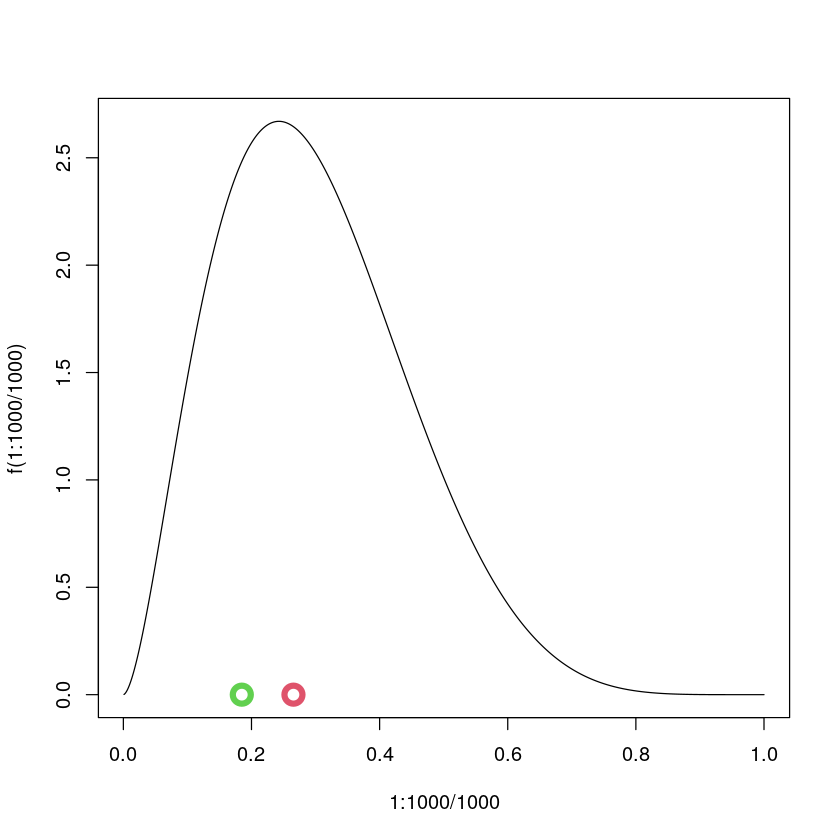

In [69]:
plot(1:1000/1000,f(1:1000/1000),type='l')
points(0.1848823,0,col=3,cex=2,lwd=5)
points(0.2655087,0,col=2,cex=2,lwd=5)

`-` 초록색이 새로운 제안이다. 

`-` 빨간색에 비하여 부족해 보인다. 

In [70]:
print(f(0.2655087)) ## 빨간색
print(f(0.1848823)) ## 초록색

[1] 2.644806
[1] 2.482678


`-` 그래도 이동한다. 

In [71]:
print(round(f(0.1848823)/f(0.2655087),4))

[1] 0.9387


`-` 무려 $93.87\%$의 확률로!

`-` 매트로폴리스의 알고리즘은 대부분의 경우에서 $x_t\neq x_{t+1}$이다. 즉 $x_t$와 $x_{t+1}$이 좀 더 덜 연관되어 보인다. 

`-` 특히 위의 (2)는 아래그림에서 $y$축의 값이 일정한 구간이 짧다는것을 의미한다. 

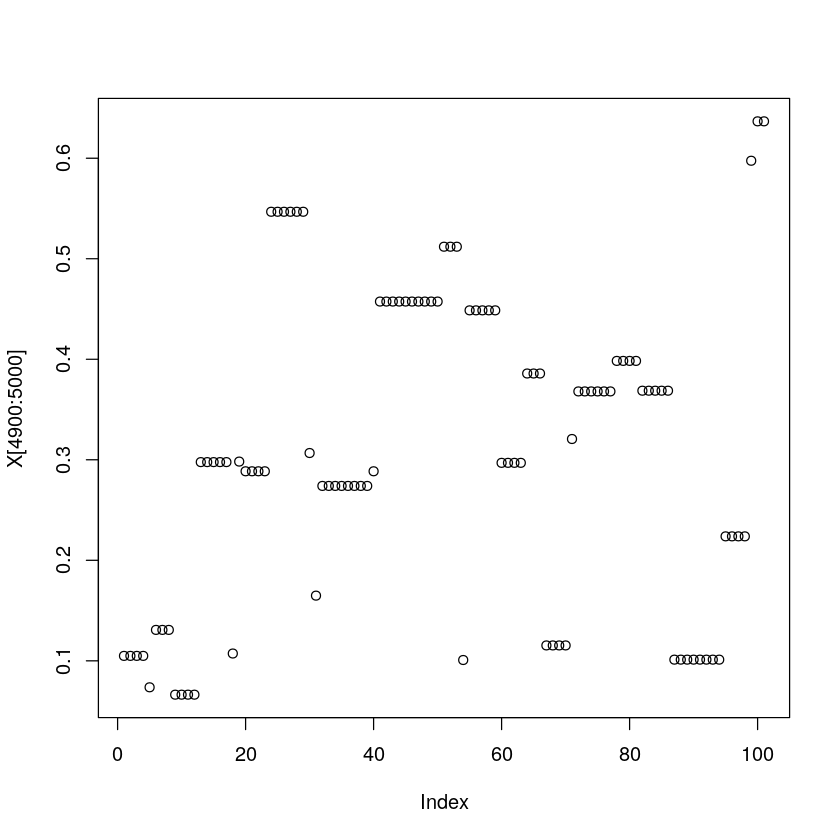

In [72]:
plot(X[4900:5000])

`-` 그런데 매트로폴리스의 제안이 과연 아래의 detailed balance condition을 만족할까? 

$$P(x_{t+1}|x_t)f(x_t)=P(x_t|x_{t+1})f(x_{t+1}) \quad \cdots (\star)$$

`-` 계산의 편의성을 위해서 대충 아래와 같이 변수 $A$, $B$를 정하자. 
$$
\begin{cases}
P(x_{t+1}|x_t)=\min\left(1, \frac{f(x_{t+1})}{f(x_t)} \right):=A \\
P(x_{t}|x_{t+1})=\min\left(1, \frac{f(x_{t})}{f(x_{t+1})} \right):=B
\end{cases}
$$

`-` 그럼 detailed balance condition $(\star)$는 아래와 같이 된다. 

$$Af(x_t)=Bf(x_{t+1}) \quad \cdots (\star)$$

`-` 경우1: $f(x_{t+1})>f(x_t)$ 라고 가정하자. 그렇다면 $A=1$, $B=\frac{f(x_t)}{f(x_{t+1})}$ 이 된다. 따라서 detailed balance condition 이 성립한다. 

`-` 경우2: $f(x_{t+1})<f(x_{t})$ 이라고 하자. 그렇다면 $A=\frac{f(x_{t+1})}{f(x_t)}$, $B=1$ 이 된다. 따라서 detailed balance condition 이 성립한다. 

> Note: $f(x_{t+1})=f(x_t)$ 이면 $A=B=1$ 이 되고 그냥 성립한다... 

`-` 성립한다. 

#### (초보단계의) 메트로폴리스-헤이스팅스 알고리즘 

`-` 메트로폴리스의 알고리즘을 요약하면 아래와 같다. 

(1) $X_1$에 아무값이나 넣는다. 

(2) $t=2,3,\dots$에 대하여 아래를 반복한다. 
- $Y_t$을 균등분포에서 뽑는다. 
- $\min\left(1, \frac{f(Y_{t})}{f(x_t)} \right)$의 확률로 $X_{t+1}=Y_t$을 선택하고 그 외의 확률로 $X_{t+1}=X_{t}$을 선택한다. 

In [73]:
X<-rep(0.1,5000)
for (i in 2:5000){
    Y<-runif(1)
    acceptance_prob<- min(1,f(Y)/f(X[i]))
    U_ <- runif(1)
    X[i]<- Y * (U_<acceptance_prob) + X[i-1] * (U_>acceptance_prob)
}

In [74]:
acceptance_prob

[1] 1

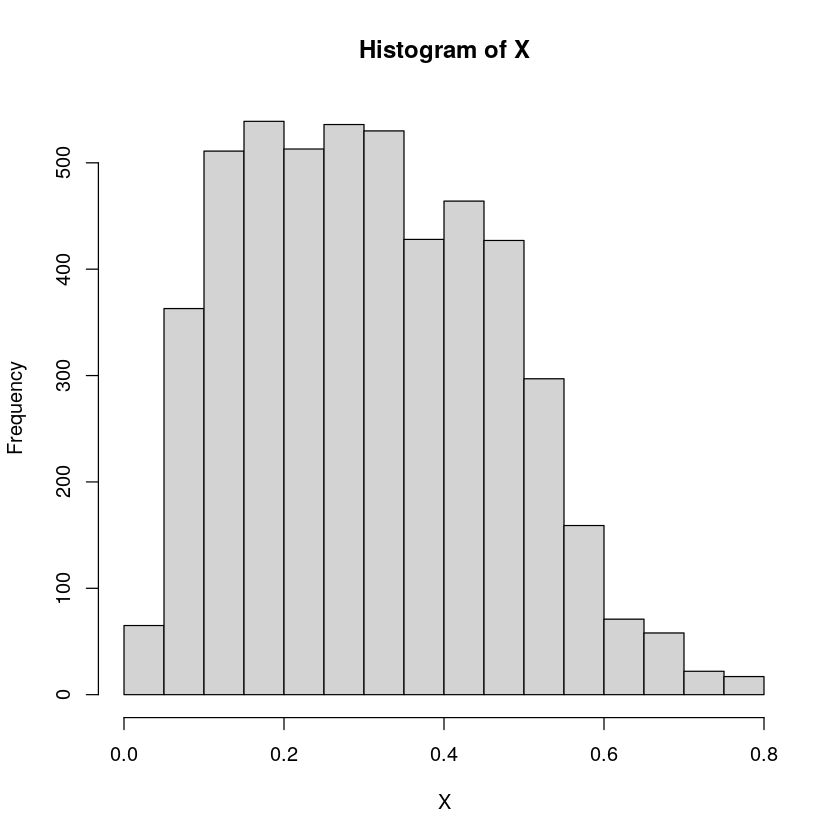

In [79]:
hist(X)

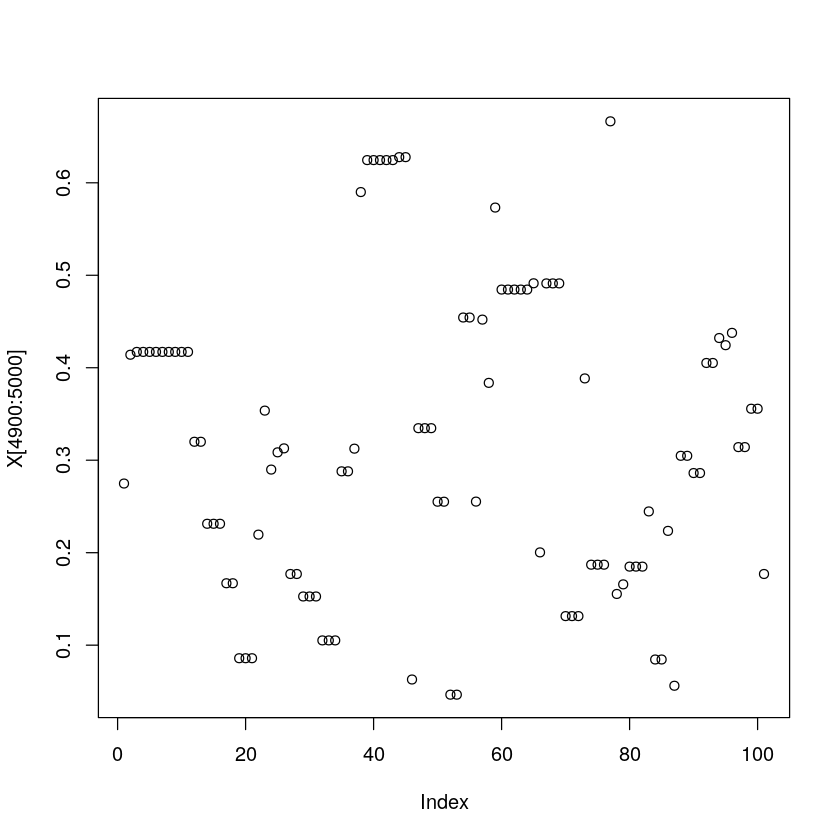

In [77]:
plot(X[4900:5000])

### 시도4 

`-` $Y$를 균등분포가 아닌 다른분포에서 뽑아도 가능할 것 같다. 

`-` 예를들면 $Y\sim Beta(2,6)$에서 추출한다고 해보자. 

In [81]:
g<-function(x){
    alpha=2
    beta=6
    gamma(alpha+beta)/gamma(alpha)/gamma(beta) * x^(alpha-1) * (1-x)^(beta-1)
}

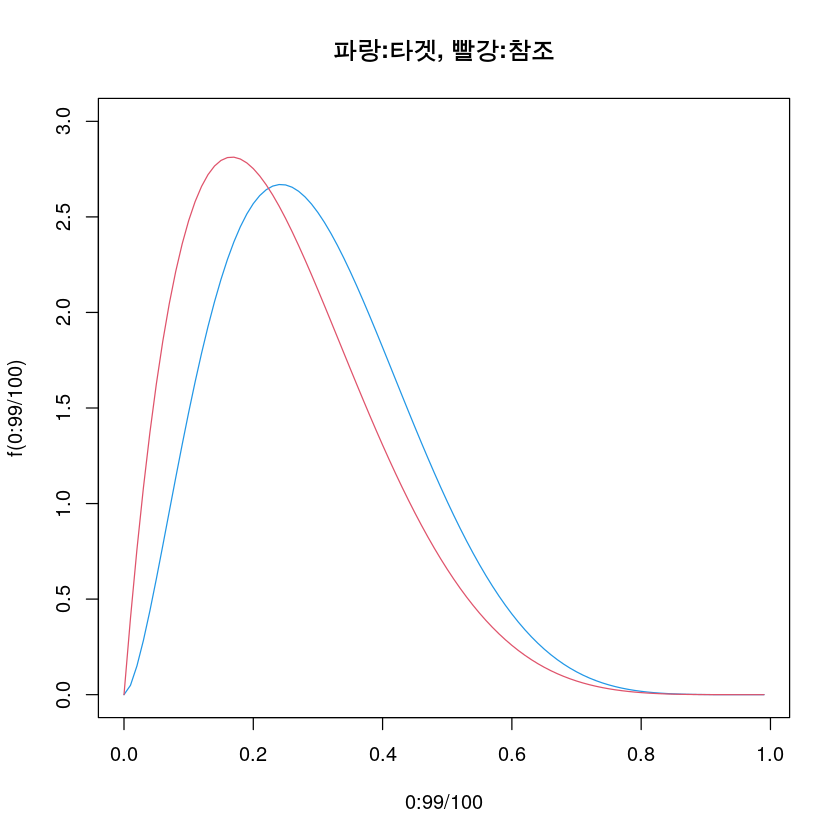

In [91]:
plot(0:99/100,f(0:99/100),type='l',col=4,ylim=c(0,3),main='파랑:타겟, 빨강:참조')
lines(0:99/100,g(0:99/100),col=2)

In [105]:
set.seed(1)
Y=rbeta(1,shape1=2,shape2=6)
Y

[1] 0.1516497

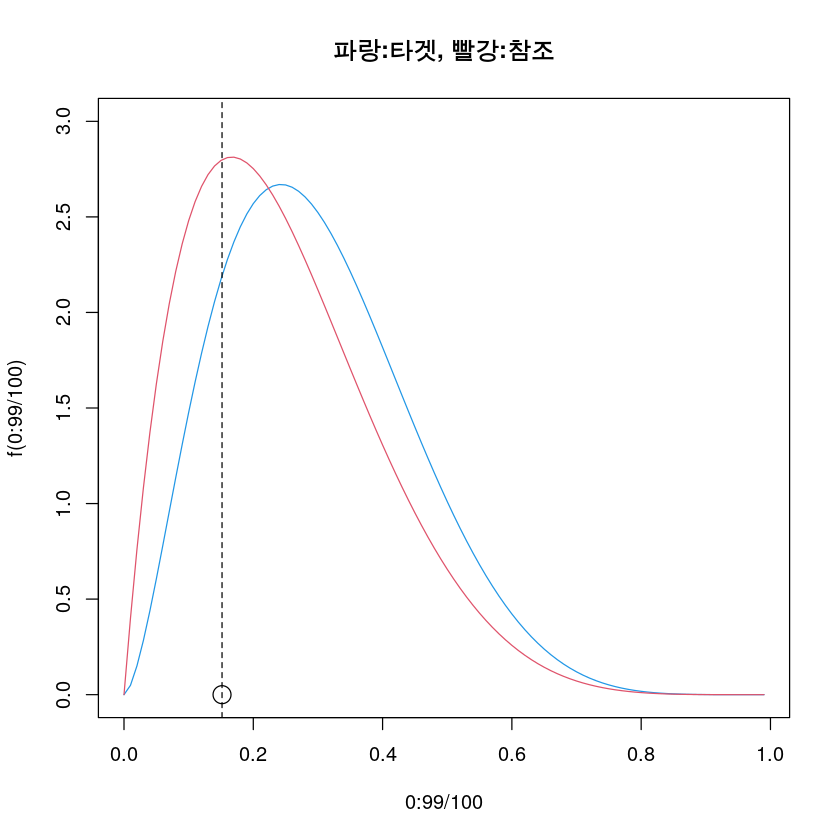

In [113]:
plot(0:99/100,f(0:99/100),type='l',col=4,ylim=c(0,3),main='파랑:타겟, 빨강:참조')
lines(0:99/100,g(0:99/100),col=2)
points(Y,0,cex=2); abline(v=Y,lty=2)

참조분포가 균등분포였으면 $Y$를 타겟분포의 샘플이라고 믿을수도 있었음. 

그런데 참조분포가 붉은선의 pdf를 가지므로 $Y$가 타겟분포의 샘플이라고 믿기 어려워 졌음. 

수락확률이 수정되어야한다. 

- 기존의 수락확률: $\min\left(1, \frac{f(Y_{t})}{f(x_t)} \right)$

- 수정된 수락확률: $\min\left(1, \frac{f(Y_{t})g(x_t)}{f(x_t)g(Y_t)} \right)$

In [115]:
X<-rep(0.1,5000)
for (i in 2:5000){
    Y<-rbeta(1,shape1=2,shape2=6)
    acceptance_prob<- min(1,f(Y)*g(X[i])/f(X[i])/g(Y))
    U_ <- runif(1)
    X[i]<- Y * (U_<acceptance_prob) + X[i-1] * (U_>acceptance_prob)
}

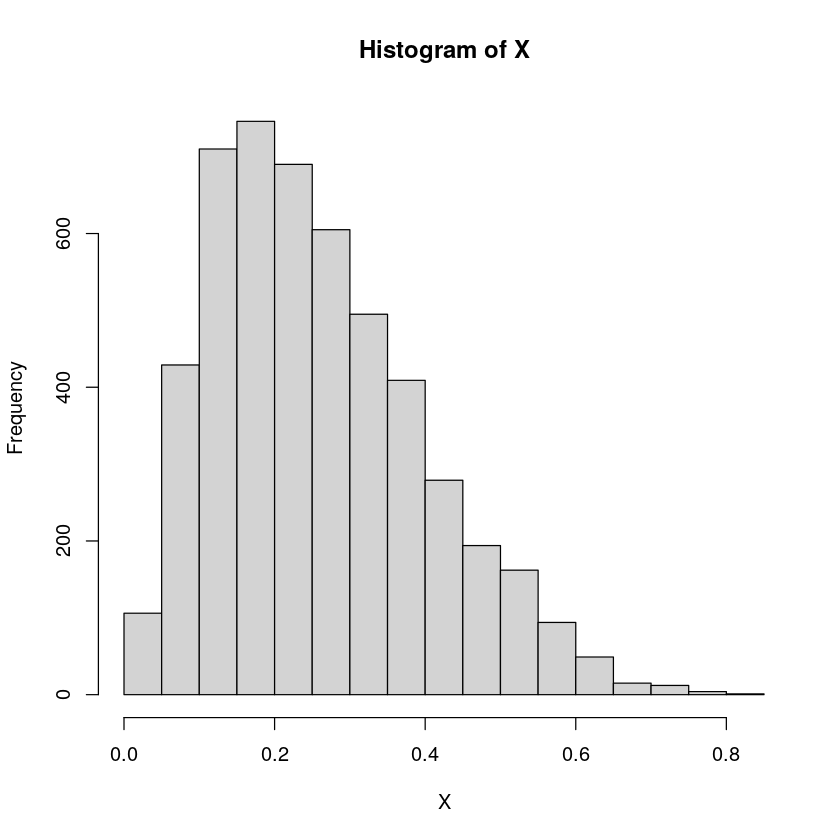

In [116]:
hist(X)

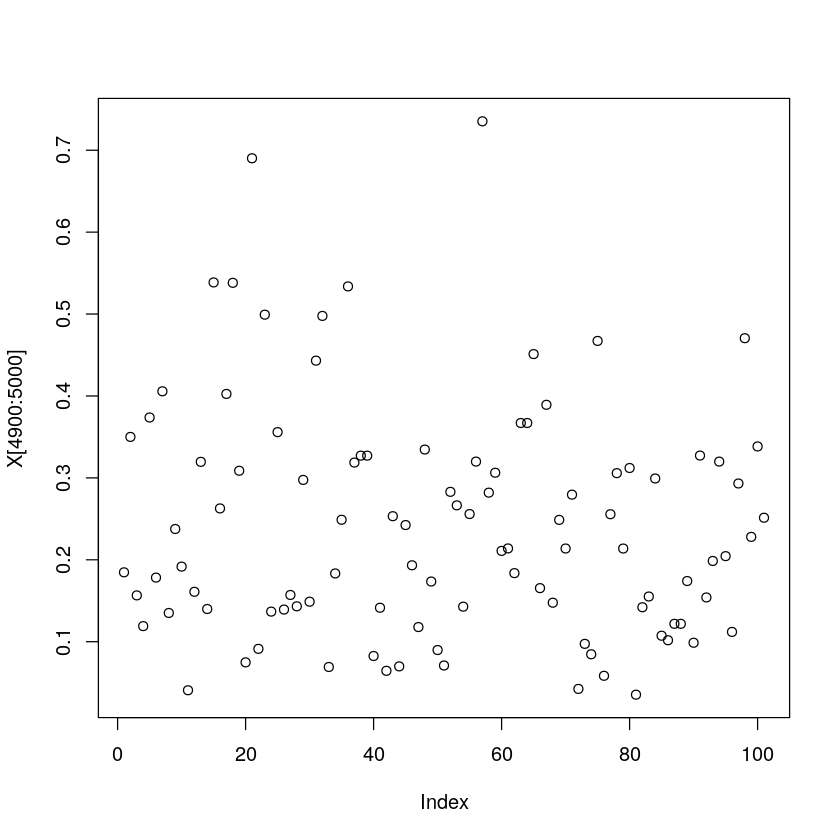

In [117]:
plot(X[4900:5000])

***[수정된 알고리즘]***

(1) $X_1$에 아무값이나 넣는다. 

(2) $t=2,3,\dots$에 대하여 아래를 반복한다. 
- $Y_t$을 $g$에서 뽑는다. 
- $\min\left(1, \frac{f(Y_{t})g(x_t)}{f(x_t)g(Y_t)} \right)$의 확률로 $X_{t+1}=Y_t$을 선택하고 그 외의 확률로 $X_{t+1}=X_{t}$을 선택한다. 